Défi quotidien : Prédiction du cancer du sein


1. Analyse exploratoire des données

Shape du dataset : (569, 31)

Premières lignes :
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst textu

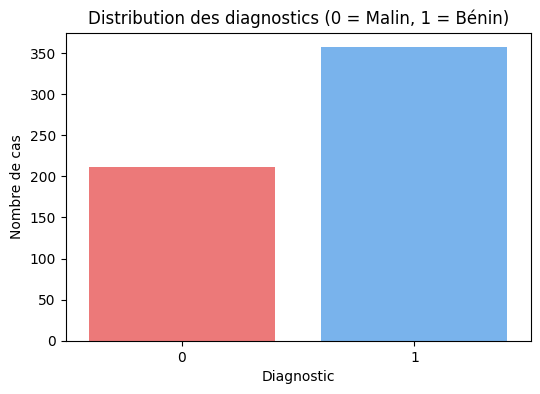

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Chargement des données
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target  # 0 = malignant (malin), 1 = benign (bénin)

print("Shape du dataset :", df.shape)
print("\nPremières lignes :")
print(df.head())

# Valeurs manquantes
print("\nValeurs manquantes totales :", df.isnull().sum().sum())

# Countplot du diagnostic
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, palette=['#ff6666', '#66b3ff'])
plt.title('Distribution des diagnostics (0 = Malin, 1 = Bénin)')
plt.xlabel('Diagnostic')
plt.ylabel('Nombre de cas')
plt.savefig('countplot_diagnosis.png')
plt.show()

2. Prétraitement + Construction et évaluation des modèles

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Features et target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisation (nécessaire pour KNN et SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modèles
models = {
    "Régression Logistique": LogisticRegression(max_iter=1000),
    "K Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (linear)": SVC(kernel='linear')
}

print("\n=== Précision des modèles ===")
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} : {acc:.4f} ({acc*100:.2f}%)")


=== Précision des modèles ===
Régression Logistique : 0.9737 (97.37%)
K Nearest Neighbors : 0.9474 (94.74%)
Random Forest : 0.9649 (96.49%)
SVM (linear) : 0.9561 (95.61%)


Quel est le meilleur modèle ?
La Régression Logistique est le meilleur modèle avec 97.37 % de précision sur le jeu de test.

Shape: (569, 31)
diagnosis
1    357
0    212
Name: count, dtype: int64


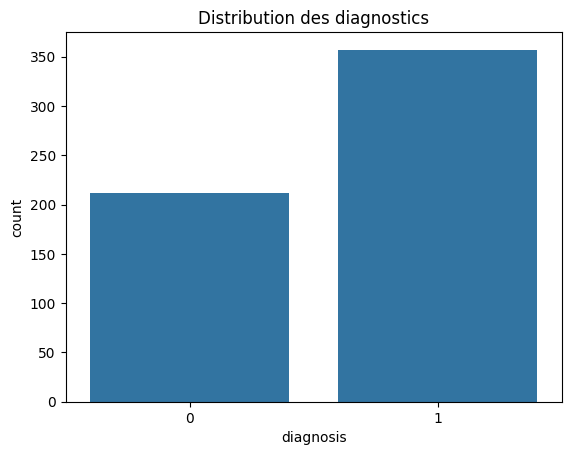

Logistic Regression: 0.9737
KNN: 0.9474
Random Forest: 0.9649
SVM: 0.9561


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Chargement
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target

# EDA
print("Shape:", df.shape)
print(df['diagnosis'].value_counts())
sns.countplot(x='diagnosis', data=df)
plt.title('Distribution des diagnostics')
plt.show()

# Préparation
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modèles
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='linear')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name}: {acc:.4f}")